# Building a Rainfall Prediction Classifier

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

### Load the data

In [2]:
data = pd.read_csv('weatherAUS_2.csv')
data.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
10200,2012-03-18,CoffsHarbour,20.2,25.3,0.4,2.4,7.7,S,63.0,SW,...,68.0,49.0,1018.2,1017.3,6.0,3.0,21.0,24.6,No,Yes
115698,2012-01-14,PearceRAAF,23.9,31.8,0.0,NaN,9.5,NaN,NaN,E,...,47.0,43.0,1010.4,1008.0,NaN,NaN,28.0,30.7,No,No
70189,2016-12-04,Melbourne,12.7,31.7,0.0,5.6,4.8,N,44.0,NE,...,57.0,28.0,1010.1,1006.0,7.0,8.0,18.1,30.9,No,Yes
2031,2014-09-21,Albury,3.4,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,67.0,43.0,1030.6,1027.5,NaN,NaN,12.2,18.6,No,NaN
52737,2010-10-07,MountGinini,3.4,11.7,6.0,NaN,NaN,W,54.0,WSW,...,48.0,42.0,NaN,NaN,NaN,NaN,5.5,10.1,Yes,No


### Drop all rows with missing values

In [3]:
data.count()

Date             145460
Location         145460
MinTemp          143975
MaxTemp          144199
Rainfall         142199
Evaporation       82670
Sunshine          75625
WindGustDir      135134
WindGustSpeed    135197
WindDir9am       134894
WindDir3pm       141232
WindSpeed9am     143693
WindSpeed3pm     142398
Humidity9am      142806
Humidity3pm      140953
Pressure9am      130395
Pressure3pm      130432
Cloud9am          89572
Cloud3pm          86102
Temp9am          143693
Temp3pm          141851
RainToday        142199
RainTomorrow     142193
dtype: int64

In [4]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56420 entries, 6049 to 142302
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           56420 non-null  object 
 1   Location       56420 non-null  object 
 2   MinTemp        56420 non-null  float64
 3   MaxTemp        56420 non-null  float64
 4   Rainfall       56420 non-null  float64
 5   Evaporation    56420 non-null  float64
 6   Sunshine       56420 non-null  float64
 7   WindGustDir    56420 non-null  object 
 8   WindGustSpeed  56420 non-null  float64
 9   WindDir9am     56420 non-null  object 
 10  WindDir3pm     56420 non-null  object 
 11  WindSpeed9am   56420 non-null  float64
 12  WindSpeed3pm   56420 non-null  float64
 13  Humidity9am    56420 non-null  float64
 14  Humidity3pm    56420 non-null  float64
 15  Pressure9am    56420 non-null  float64
 16  Pressure3pm    56420 non-null  float64
 17  Cloud9am       56420 non-null  float64
 18  Cloud3p

### Update the names of rain columns

In [5]:
data = data.rename(columns={
    'RainToday' : 'RainYesterday',
    'RainTomorrow' : 'RainToday'        
                            })

In [6]:
data['Location'].unique()

array(['Cobar', 'CoffsHarbour', 'Moree', 'NorfolkIsland', 'Sydney',
       'SydneyAirport', 'WaggaWagga', 'Williamtown', 'Canberra', 'Sale',
       'MelbourneAirport', 'Melbourne', 'Mildura', 'Portland', 'Watsonia',
       'Brisbane', 'Cairns', 'Townsville', 'MountGambier', 'Nuriootpa',
       'Woomera', 'PerthAirport', 'Perth', 'Hobart', 'AliceSprings',
       'Darwin'], dtype=object)

### Location selection

In [7]:
data = data[data['Location'].isin(['Melbourne','MelbourneAirport','Watsonia','Sydney'])]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9247 entries, 31168 to 80997
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9247 non-null   object 
 1   Location       9247 non-null   object 
 2   MinTemp        9247 non-null   float64
 3   MaxTemp        9247 non-null   float64
 4   Rainfall       9247 non-null   float64
 5   Evaporation    9247 non-null   float64
 6   Sunshine       9247 non-null   float64
 7   WindGustDir    9247 non-null   object 
 8   WindGustSpeed  9247 non-null   float64
 9   WindDir9am     9247 non-null   object 
 10  WindDir3pm     9247 non-null   object 
 11  WindSpeed9am   9247 non-null   float64
 12  WindSpeed3pm   9247 non-null   float64
 13  Humidity9am    9247 non-null   float64
 14  Humidity3pm    9247 non-null   float64
 15  Pressure9am    9247 non-null   float64
 16  Pressure3pm    9247 non-null   float64
 17  Cloud9am       9247 non-null   float64
 18  Cloud3pm

### Create a function to map dates to seasons

In [8]:
def date_to_season(date):
    month = int(date.split('-')[1])
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

In [9]:
data['Season'] = data['Date'].apply(date_to_season)
data.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
64351,2009-06-10,MelbourneAirport,4.4,10.4,3.4,2.8,3.2,SW,56.0,WSW,...,88.0,1019.5,1021.4,7.0,7.0,5.9,7.7,Yes,Yes,Winter
78603,2010-09-07,Watsonia,6.6,15.5,3.8,2.6,5.3,NW,41.0,NNE,...,56.0,1027.5,1025.2,7.0,5.0,7.9,14.0,Yes,No,Spring
79923,2014-07-17,Watsonia,7.7,11.9,1.4,2.8,8.1,W,52.0,NNW,...,60.0,1009.2,1008.9,2.0,7.0,8.9,9.8,Yes,Yes,Winter
64964,2011-02-13,MelbourneAirport,9.1,20.4,0.0,4.8,7.4,S,44.0,NNE,...,50.0,1023.2,1023.0,7.0,5.0,12.3,19.4,No,No,Summer
66479,2015-07-06,MelbourneAirport,6.5,11.4,1.8,4.0,0.2,N,57.0,NNE,...,66.0,1016.8,1015.6,7.0,8.0,6.7,10.0,Yes,Yes,Winter


In [10]:
data = data.drop(['Date'],axis=1)
data.sample(5)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
66966,MelbourneAirport,7.4,28.3,0.0,5.6,11.8,WNW,70.0,NNE,NNW,...,16.0,1011.3,1005.1,5.0,2.0,18.4,27.2,No,No,Spring
67777,Melbourne,17.5,23.5,0.0,7.0,7.5,SSE,48.0,S,S,...,45.0,1014.8,1015.9,7.0,2.0,18.9,21.6,No,No,Summer
67259,Melbourne,7.3,19.3,0.4,1.4,10.0,N,41.0,N,NNE,...,32.0,1025.8,1020.9,1.0,3.0,8.9,18.4,No,No,Winter
80903,Watsonia,14.5,25.7,0.0,2.0,9.0,S,33.0,SSE,SSW,...,53.0,1019.9,1018.0,7.0,7.0,17.2,24.7,No,No,Autumn
66067,MelbourneAirport,12.2,22.1,0.0,4.2,2.9,WSW,48.0,N,SSW,...,77.0,1020.0,1018.9,6.0,5.0,15.4,17.3,No,No,Autumn


### Define the feature and the target

In [11]:
X = data.drop(['Season'],axis=1)
y = data['Season']

### The balance of the classes

In [12]:
y.value_counts()

Season
Autumn    2384
Spring    2355
Winter    2340
Summer    2168
Name: count, dtype: int64

### Spilt the the data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### Define numerical and categorical

In [14]:
num_features = X_train.select_dtypes(include=['number']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object','category']).columns.tolist()

### Define separate transformers

In [15]:
num_transformer = Pipeline(steps=[
    ('scaler',StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

### Combine the transformers

In [16]:
preprocessor = ColumnTransformer(transformers=[
    ('num',num_transformer,num_features),
    ('cat',cat_transformer,cat_features)
])

### Create a pipeline by combinig the preprocessing with a Random Forest classifier

In [21]:
pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(random_state=42))
])

### Define a parameter grid

In [17]:
param_grid = {
    'classifier__n_estimators':[50,100,200],
    'classifier__max_depth':[None,10,20],
    'classifier__min_samples_split':[2,5,10],
}

### Select a cross validation method

In [18]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

### Fit GridSearchCV to the pipeline

In [22]:
grid_search = GridSearchCV(pipeline,param_grid,cv=cv,scoring='accuracy',verbose=2)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   1.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   1.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   1.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   1.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   1.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',
                                                                          'Pressure9am',
                                                                          'Pres...
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Location',
                                                                          'WindGustDir',
                                                                          'WindDir9am',
                                                                          'WindDir3pm',
                                                                          'RainYesterday',
                                                                          'RainToday'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=2)

### print the the best parameters and the best cross-validation score

In [23]:
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))

Best parameters found:  {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best cross-validation accuracy: 0.75


### Get the model prediction from the grid search

In [24]:
y_pred = grid_search.predict(X_test)

### Print the classification report

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Autumn       0.73      0.59      0.65       477
      Spring       0.73      0.69      0.71       471
      Summer       0.73      0.87      0.80       434
      Winter       0.81      0.87      0.84       468

    accuracy                           0.75      1850
   macro avg       0.75      0.75      0.75      1850
weighted avg       0.75      0.75      0.75      1850



### Plot the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix')

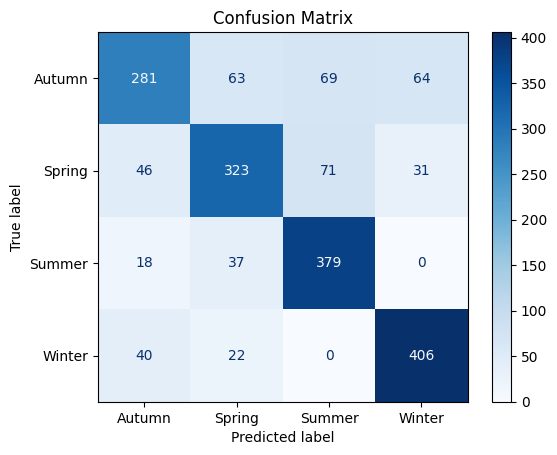

In [26]:
conf_matrix = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=grid_search.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')

### Update the pipeline and the parameter grid

In [28]:
pipeline.set_params(classifier=LogisticRegression(random_state=42))
grid_search.estimator = pipeline

pram_grid = {
    'classifier__solver':['liblinear','lbfgs'],
    'classifier__penalty':['l1','l2'],
    'classifier__class_weight':[None,'balanced'],
}

grid_search.param_grid = pram_grid

grid_search.fit(X_train,y_train)

y_pred = grid_search.predict(X_test)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   1.7s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   1.7s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   1.8s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   1.5s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   1.4s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__class_weight=None, classifi

C:\Users\ilyass\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.2s


C:\Users\ilyass\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.2s


...

[CV] END classifier__class_weight=balanced, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.3s


C:\Users\ilyass\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END classifier__class_weight=balanced, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.2s


C:\Users\ilyass\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ilyass\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10

[CV] END classifier__class_weight=balanced, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.2s


### Compare the results

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Autumn       0.63      0.56      0.59       477
      Spring       0.60      0.55      0.57       471
      Summer       0.68      0.77      0.72       434
      Winter       0.80      0.85      0.82       468

    accuracy                           0.68      1850
   macro avg       0.67      0.68      0.68      1850
weighted avg       0.67      0.68      0.67      1850



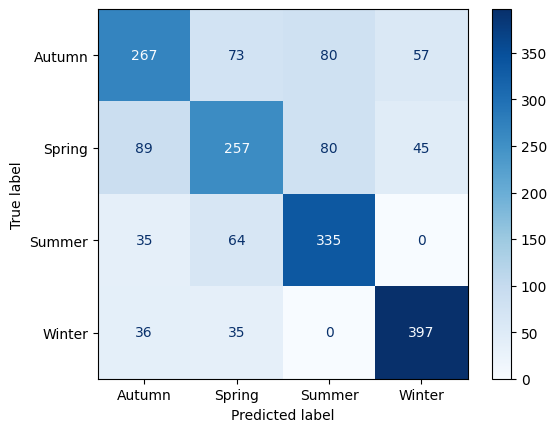

In [30]:
conf_matrix = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=grid_search.classes_)
disp.plot(cmap=plt.cm.Blues)